# Functions

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sns
import dabest
from struct import *
import osar
import scipy as sp
import re
import dabest
import warnings
import scikits.bootstrap as skb
from osar.plot_helpers.plot_helpers import r2_and_slope
import NLProcessing

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

#warnings.simplefilter(action="default", category=RuntimeWarning)

import matplotlib as mpl
from matplotlib import font_manager

# Custom font (optional)
font_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 21.44it/s]


Numba compilation complete!


## Must run

In [11]:
def chartplottingdabest(dfi, basegenotype, parameter):
    
    dfr1 = pd.DataFrame()
    for names in basegenotype:
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
        filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names] = filter1[parameter]
        dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfr1.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    
    test = dabest.load(dfr1, idx=titlelst)    
    tab = pd.concat([test.mean_diff.results['test'], test.mean_diff.results['difference']], axis = 1)
    
    arrangedsorting = tab.sort_values(by=['difference'], ascending = True).reset_index(drop=True)

    newlist = []
    for n in arrangedsorting['test']:
        newlist.append((n +" Cntrl", n))

    return dfr1, arrangedsorting['test'], newlist

def meandiffchart(dfi, basegenotype, parameter):
    
    dfr1 = pd.DataFrame()
    for names in basegenotype:
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
        filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names] = filter1[parameter]
        dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfr1.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    
    test = dabest.load(dfr1, idx=titlelst, ci=90)    
    tab = pd.concat([test.mean_diff.results['test'], round(test.mean_diff.results['difference'],3)], axis = 1)
    tab.rename(columns = {'test':'MBON', 'difference':parameter}, inplace = True)

    return tab

In [12]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp

root = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\"
filedate = "20260126"

In [13]:
respondertype = "ACR"
filepath = root + filedate + "_" + respondertype + "_totalcompilation.csv"
df2= pd.read_csv(filepath)

basegenotype = df2['driver'].unique()

#dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full')].copy()
dfi=df2[(df2['light_intensity']=='Full')].copy()
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)

In [60]:
def omission(df, metric_one, metric_two):
    respon = '_' + df['responder'].unique()[0]
    tempdff = df[df['MBON'] != 'R76B09'].reset_index(drop=True) #removing outlier
    dfomitted = tempdff[~((tempdff[metric_one].abs() < 0.0) & (tempdff[metric_two].abs() < 0.0))]
    exclude = ['responder', 'MBON']
    dfomitted = dfomitted.rename(columns={col: col + respon for col in dfomitted.columns if col not in exclude})
    return dfomitted.reset_index(drop=True)

def multiresponder_osar(df2, responder):    
    from functools import reduce
    
    dfi=df2[(df2['light_intensity']=='Full')].reset_index(drop=True)  #Full light only
    dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfi.rename(columns={'driver': 'MBON'}, inplace = True)
    
    basegenotype = dfi['MBON'].unique()
    
    dfpi, sortedlist, dabestlist = chartplottingdabest(dfi, basegenotype, 'pi_smoothed_Pattern 01')
    dfspeed= chartplottingdabest(dfi, basegenotype, 'log2_speed_ratio_Pattern 01')[0]
    dfpace = chartplottingdabest(dfi, basegenotype, 'log2_pace_ratio_Pattern 01')[0]
    dfboutnumber= chartplottingdabest(dfi, basegenotype, 'bout_index_Pattern 01')[0]
    dfboutduration = chartplottingdabest(dfi, basegenotype, 'bout_duration_ratio_Pattern 01')[0]
    dfmaxvelocity = chartplottingdabest(dfi, basegenotype, 'max_velocity_ratio_Pattern 01')[0]
    dflai = chartplottingdabest(dfi, basegenotype, 'light_attraction_index_Pattern 01')[0]
    
    piplot = dabest.load(dfpi, idx=dabestlist)
    spplot = dabest.load(dfspeed, idx=dabestlist)
    pcplot = dabest.load(dfpace, idx=dabestlist) 
    bnplot = dabest.load(dfboutnumber, idx=dabestlist) 
    bdplot = dabest.load(dfboutduration, idx=dabestlist) 
    mvplot = dabest.load(dfmaxvelocity, idx=dabestlist)
    laiplot = dabest.load(dflai, idx=dabestlist)
    
    pitable = pd.DataFrame({'MBON': piplot.hedges_g.statistical_tests['test'],'Δ PI': piplot.hedges_g.statistical_tests['difference']})
    sptable = pd.DataFrame({'MBON': spplot.hedges_g.statistical_tests['test'],'Δ Log2 Speed Ratio': spplot.hedges_g.statistical_tests['difference']})
    pctable = pd.DataFrame({'MBON': pcplot.hedges_g.statistical_tests['test'],'Δ Log2 Pace Ratio': pcplot.hedges_g.statistical_tests['difference']})
    bntable = pd.DataFrame({'MBON': bnplot.hedges_g.statistical_tests['test'],'Δ Bout Number Index': bnplot.hedges_g.statistical_tests['difference']})
    bdtable = pd.DataFrame({'MBON': bdplot.hedges_g.statistical_tests['test'],'Δ Bout Duration Ratio': bdplot.hedges_g.statistical_tests['difference']})
    mvtable = pd.DataFrame({'MBON': mvplot.hedges_g.statistical_tests['test'],'Δ Max Velocity Index': mvplot.hedges_g.statistical_tests['difference']})
    laitable = pd.DataFrame({'MBON': laiplot.hedges_g.statistical_tests['test'],'Δ LAI': laiplot.hedges_g.statistical_tests['difference']})
    
    tabletotallst = [pitable, sptable, pctable, bntable, bdtable, mvtable, laitable]

    tabletotal = reduce(lambda left, right: pd.merge(left, right, on =['MBON'], how = "outer"), tabletotallst)

    tabletotal['responder'] = responder
    
    return tabletotal

In [15]:
filepathACR = root + filedate + "_ACR_totalcompilation.csv"
filepathCR2 = root + filedate + "_Chrimson2_totalcompilation.csv"

dffileACR= pd.read_csv(filepathACR, index_col=0)
dffileCR2= pd.read_csv(filepathCR2, index_col=0)

dffACR = multiresponder_osar(dffileACR, "ACR")  #full light only
dffCR2 = multiresponder_osar(dffileCR2, "Chrimson2")

dfmultiresponderosar = pd.concat([dffACR, dffCR2]).reset_index(drop=True)
dfmultiresponderosar['genotypeandresponder'] = dfmultiresponderosar['MBON'] + "_" + dfmultiresponderosar['responder']

In [ ]:
mbonlist_csv = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\MBONlist.csv"


## Scatter plot

In [ ]:

respon = '_' + dffCR2['responder'].unique()[0]
tempdff = dffCR2[dffCR2['MBON'] != 'R76B09'].reset_index(drop=True) #removing outlier
dfomitted = tempdff[~((tempdff[metric_one].abs() < 0.0) & (tempdff[metric_two].abs() < 0.0))]
exclude = ['responder', 'MBON']
#dfomitted = dfomitted.rename(columns={col: col + respon for col in dfomitted.columns if col not in exclude})

dfomitted

,MBON,Δ PI,Δ Log2 Speed Ratio,Δ Log2 Pace Ratio,Δ Bout Number Index,Δ Bout Duration Ratio,Δ Max Velocity Index,Δ LAI,responder
0,MB018B,0.402923,0.113780,-0.189276,0.145590,0.155396,0.347169,0.284107,Chrimson2
1,MB077B,-0.153291,0.103042,0.120246,-0.071929,-0.415538,-0.044609,0.098745,Chrimson2
2,MB082C,-0.162254,0.254670,-0.043143,0.098243,0.234761,0.013093,0.243158,Chrimson2
3,MB093C,0.153830,-0.423383,0.487373,-0.456139,-0.043779,-0.078172,-0.003271,Chrimson2
4,MB112C,0.244231,0.186355,0.392273,0.171952,0.214931,0.395470,0.065169,Chrimson2
5,MB210B,-0.107952,0.090343,0.201456,-0.101548,0.040454,0.275371,-0.079083,Chrimson2
6,MB242A,-0.131655,0.062215,0.178585,-0.117794,-0.002582,0.151006,0.138073,Chrimson2
7,MB310C,-0.108502,-0.028198,0.078008,0.274312,-0.075382,0.296372,0.136500,Chrimson2
8,MB319C,0.298763,-0.517077,-0.249884,0.094599,0.150560,-0.192760,0.281328,Chrimson2
9,MB323B,-0.156574,0.519993,0.656155,-0.181175,-0.203544,0.468099,-0.205157,Chrimson2


Text(0.02, 0.05, 'R²: 0.13\nCI:0.014, 0.63')

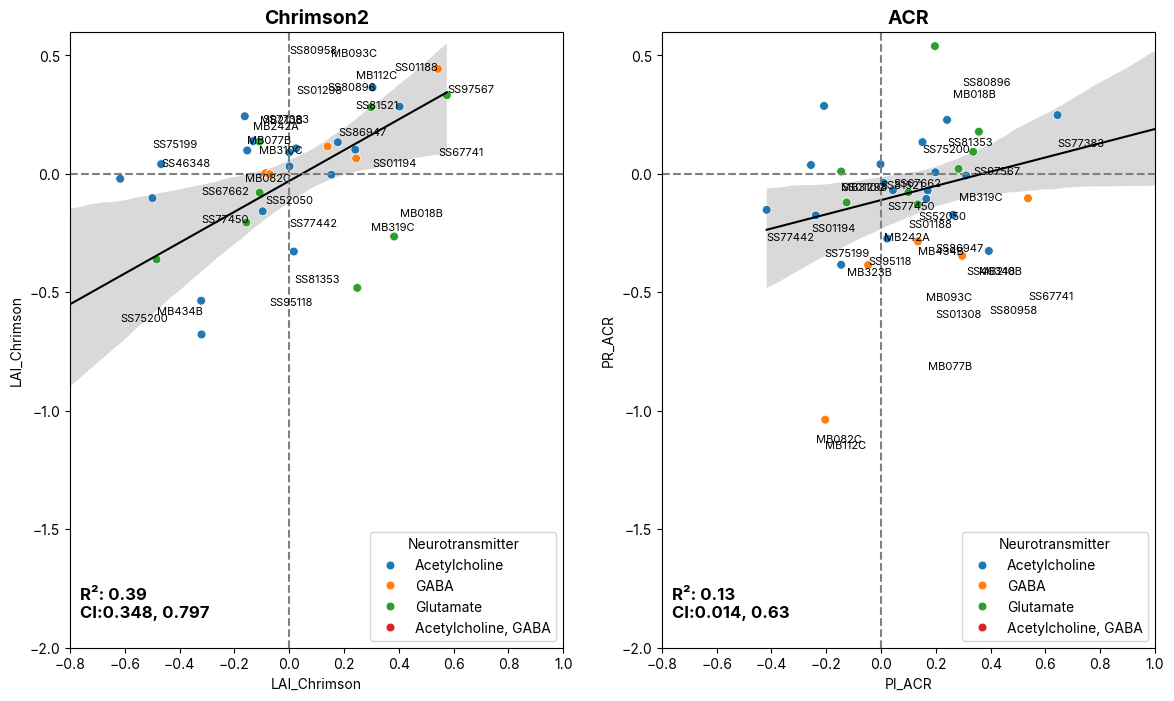

In [64]:
#only for values above magnitude of 0.2 and no VT999036
import scipy.stats

plt.rcParams["font.family"] = "Inter"

figosarplot, axscatter_o = plt.subplots(1,2, figsize=(14,8), sharey='row')

metric_one = "Δ PI"
metric_two = "Δ LAI"

df02omission_Chrimson2 = omission(dffCR2, metric_one, metric_two)
df02omission_ACR = omission(dffACR, metric_one, metric_two)

lobelocation_Cr2 = NLProcessing.generate_lobelocation(df02omission_Chrimson2['MBON'].tolist(), mbonlist_csv)
lobelocation_ACR = NLProcessing.generate_lobelocation(df02omission_Chrimson2['MBON'].tolist(), mbonlist_csv)

sns.regplot(x= metric_one + "_Chrimson2", y= metric_two + "_Chrimson2", data=df02omission_Chrimson2, ci = 95, scatter = False, line_kws={"color": "black", 'lw': 1.5}, ax=axscatter_o[0]) 
sns.scatterplot(x= metric_one + "_Chrimson2", y= metric_two + "_Chrimson2", data=df02omission_Chrimson2, s = 40, hue =lobelocation_Cr2['Neurotransmitter'] , ax = axscatter_o[0])

## can do for LEI, or any other parameter as well
sns.regplot(x= metric_one + "_ACR", y= metric_two + "_ACR", data=df02omission_ACR, ci = 95, scatter = False, line_kws={"color": "black", 'lw': 1.5}, ax=axscatter_o[1]) 
sns.scatterplot(x= metric_one + "_ACR", y= metric_two + "_ACR", data=df02omission_ACR, s = 40, hue =lobelocation_ACR['Neurotransmitter'] , ax = axscatter_o[1])

axscatter_o[0].set_xlabel('LAI_Chrimson')
axscatter_o[1].set_xlabel('PI_ACR')
axscatter_o[0].set_ylabel('LAI_Chrimson')
axscatter_o[1].set_ylabel('PR_ACR')

# axscatter_o[0].grid()
# axscatter_o[1].grid()

axscatter_o[0].set_ylim([-2, 0.6])
axscatter_o[1].set_ylim([-2, 0.6])
axscatter_o[0].set_xlim([-0.8, 1])
axscatter_o[1].set_xlim([-0.8, 1])

for ax in axscatter_o:
    ax.axvline(0, c=(.5, .5, .5), ls= '--')
    ax.axhline(0, c=(.5, .5, .5), ls= '--')
    
axscatter_o[0].set_title("Chrimson2", weight = "bold", fontsize = 14)
axscatter_o[1].set_title("ACR", weight = "bold", fontsize = 14)
axscatter_o[1].yaxis.set_tick_params(labelbottom=True)

for n, k in enumerate(df02omission_Chrimson2['MBON']):
    axscatter_o[0].annotate(k, (df02omission_Chrimson2.loc[n,"Δ PI_Chrimson2"], df02omission_Chrimson2.loc[n,"Δ Log2 Pace Ratio_Chrimson2"]+0.01), fontsize = 8)

for n, k in enumerate(df02omission_ACR['MBON']):
    axscatter_o[1].annotate(k, (df02omission_ACR.loc[n,"Δ PI_ACR"], df02omission_ACR.loc[n,"Δ Log2 Pace Ratio_ACR"]+0.01), fontsize = 8)

#chrimson2
pearsonscorrelation_cr2 = scipy.stats.pearsonr(df02omission_Chrimson2[metric_one + "_Chrimson2"], df02omission_Chrimson2[metric_two + "_Chrimson2" ]) #correlation instead of linear regression: trying to find the relationship rather than causation    
civallow_cr2 = pearsonscorrelation_cr2.confidence_interval(confidence_level=0.95)[0] 
civalhigh_cr2 = pearsonscorrelation_cr2.confidence_interval(confidence_level=0.95)[1]  
axscatter_o[0].annotate(f"R²: {round(pearsonscorrelation_cr2[0],3)**2:.2f}" + "\nCI:" + str(round(civallow_cr2,3)) + ", " + str(round(civalhigh_cr2,3)), (0.02, 0.05), 
                        ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 12)


#Acr
pearsonscorrelation_acr = scipy.stats.pearsonr(df02omission_ACR[metric_one + "_ACR"], df02omission_ACR[metric_two + "_ACR"]) #correlation instead of linear regression: trying to find the relationship rather than causation    
civallow_acr = pearsonscorrelation_acr.confidence_interval(confidence_level=0.95)[0] 
civalhigh_acr = pearsonscorrelation_acr.confidence_interval(confidence_level=0.95)[1]   
axscatter_o[1].annotate(f"R²: {round(pearsonscorrelation_acr[0],3)**2:.2f}" + "\nCI:" + str(round(civallow_acr,3)) + ", " + str(round(civalhigh_acr,3)), (0.02, 0.05), 
                        ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 12)
    

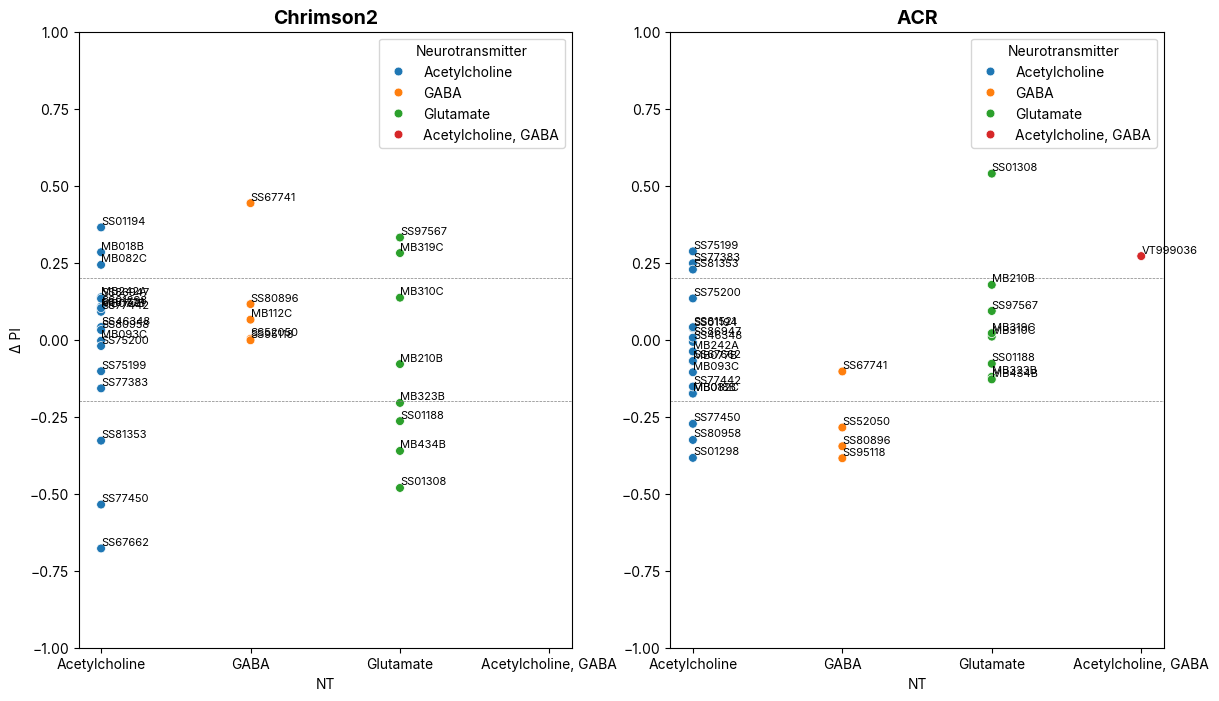

In [78]:
#only for values above magnitude of 0.2 and no VT999036
import scipy.stats

plt.rcParams["font.family"] = "Inter"

figosarplot, axscatter_o = plt.subplots(1,2, figsize=(14,8), sharey='row')

metric_one = "Δ PI"
metric_two = "Δ LAI"

df02omission_Chrimson2 = omission(dffCR2, metric_one, metric_two)
df02omission_ACR = omission(dffACR, metric_one, metric_two)

lobelocation_Cr2 = NLProcessing.generate_lobelocation(df02omission_Chrimson2['MBON'].tolist(), mbonlist_csv)
lobelocation_ACR = NLProcessing.generate_lobelocation(df02omission_Chrimson2['MBON'].tolist(), mbonlist_csv)

df_nt_chrimson2 = df02omission_Chrimson2.merge(lobelocation_Cr2[['MBON', 'Neurotransmitter']], on='MBON', how='left')
df_nt_ACR = df02omission_ACR.merge(lobelocation_Cr2[['MBON', 'Neurotransmitter']], on='MBON', how='left')

sns.scatterplot(x= "Neurotransmitter", y= metric_two + "_Chrimson2", data=df_nt_chrimson2, s = 40, hue =lobelocation_Cr2['Neurotransmitter'] , ax = axscatter_o[0])
sns.scatterplot(x= "Neurotransmitter", y= metric_two + "_ACR", data=df_nt_ACR, s = 40, hue =lobelocation_ACR['Neurotransmitter'] , ax = axscatter_o[1])

axscatter_o[0].set_xlabel('NT')
axscatter_o[1].set_xlabel('NT')
axscatter_o[0].set_ylabel(metric_one)
axscatter_o[1].set_ylabel(metric_one)
axscatter_o[0].set_ylim([-1, 1])
axscatter_o[1].set_ylim([-1, 1])

for ax in axscatter_o:
    ax.axhline(-0.2, c=(.5, .5, .5), ls= '--', lw=0.5)
    ax.axhline(0.2, c=(.5, .5, .5), ls= '--', lw=0.5)
   
    
axscatter_o[0].set_title("Chrimson2", weight = "bold", fontsize = 14)
axscatter_o[1].set_title("ACR", weight = "bold", fontsize = 14)
axscatter_o[1].yaxis.set_tick_params(labelbottom=True)


for n, k in enumerate(df_nt_chrimson2['MBON']):
    axscatter_o[0].annotate(k, (df_nt_chrimson2.loc[n,"Neurotransmitter"], df_nt_chrimson2.loc[n,"Δ LAI_Chrimson2"]+0.01), fontsize = 8)

for n, k in enumerate(df_nt_ACR ['MBON']):
    axscatter_o[1].annotate(k, (df_nt_ACR .loc[n,"Neurotransmitter"], df_nt_ACR .loc[n,"Δ LAI_ACR"]+0.01), fontsize = 8)
    

## Plotting PI against metrics

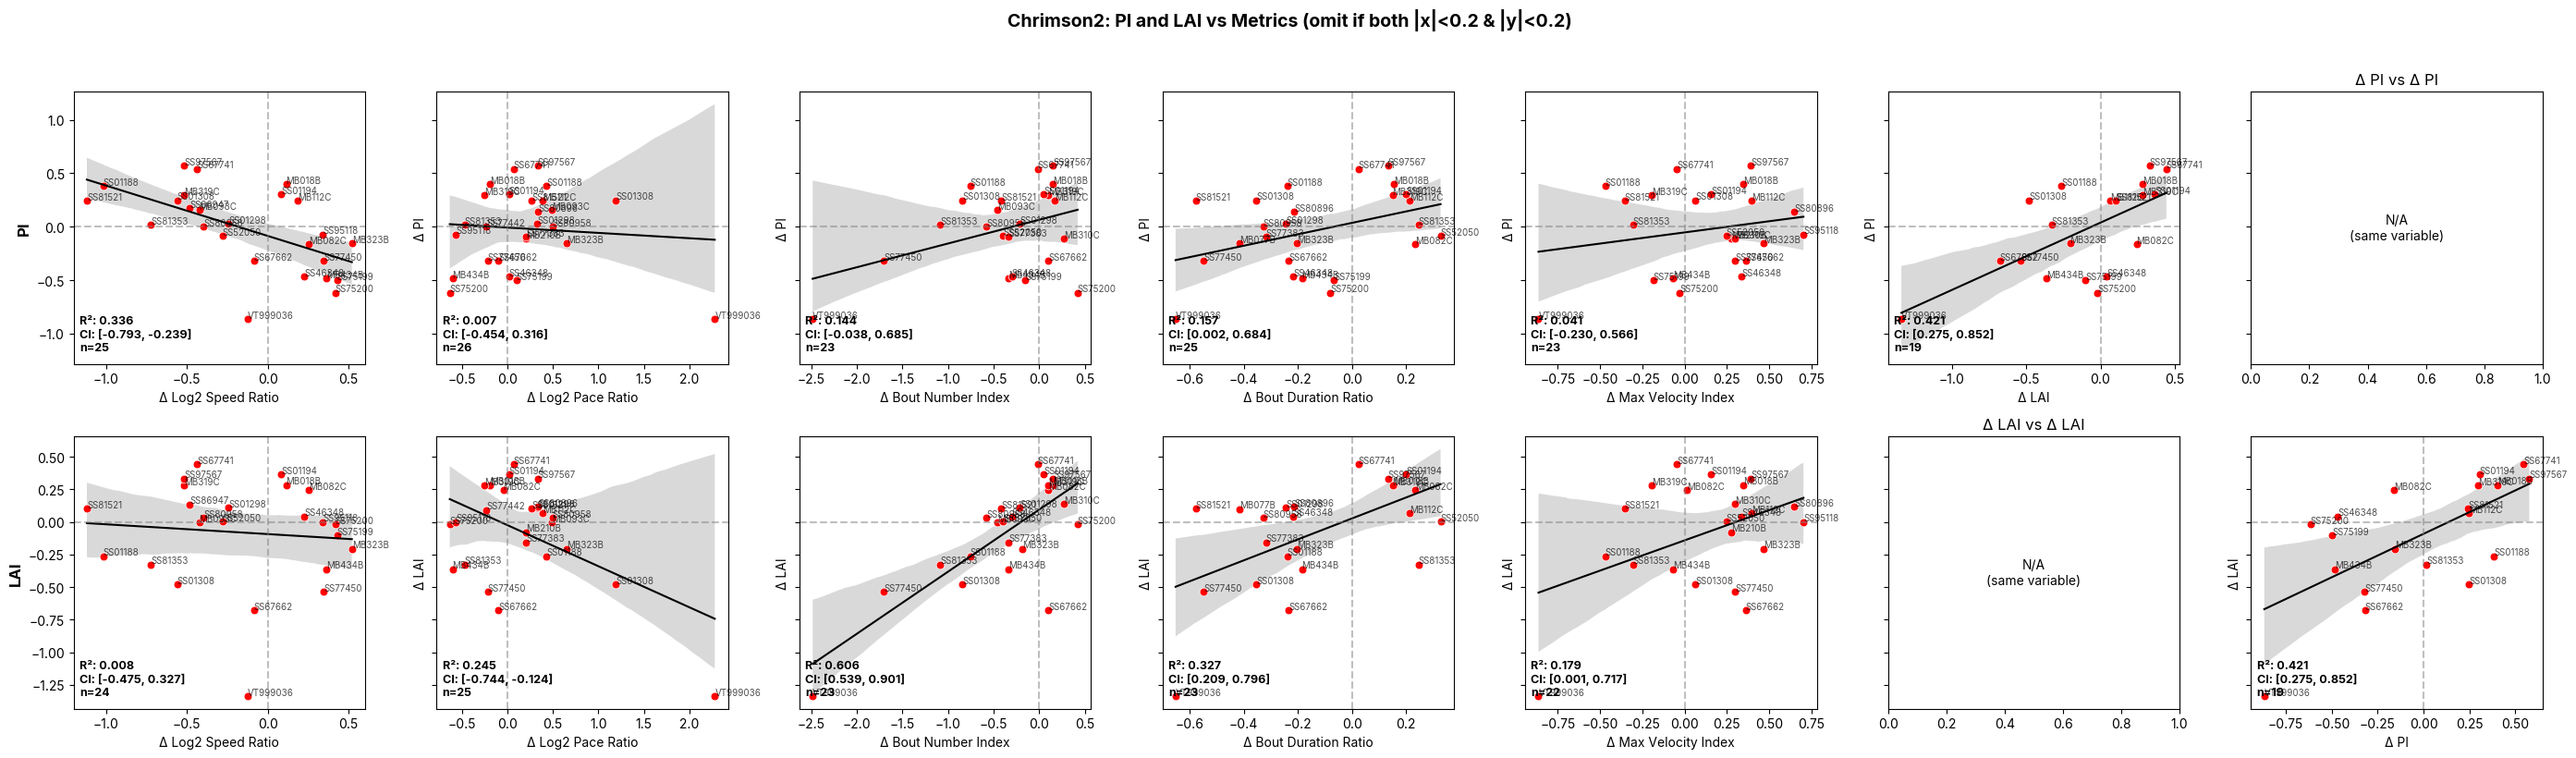

In [32]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

metrics = [
    'Δ Log2 Speed Ratio',
    'Δ Log2 Pace Ratio', 
    'Δ Bout Number Index',
    'Δ Bout Duration Ratio',
    'Δ Max Velocity Index',
    'Δ LAI' , 'Δ PI'
]

# Threshold for omission - if BOTH x and y values are below this magnitude, omit that MBON
omission_threshold = 0.2

df02omission_Chrimson2 = omission(dffCR2)
df02omission_ACR = omission(dffACR)

y_vars = ['Δ PI', 'Δ LAI']
title_prefix = "Chrimson2"
suffix = '_' + title_prefix

df_plot = df02omission_Chrimson2.copy()  
if "_ACR" in suffix:
    scatter_color = "green"    
if "_Chrimson2" in suffix:
    scatter_color = "red" 


n_metrics = len(metrics)
fig_scatter, axes = plt.subplots(2, n_metrics, figsize=(4*n_metrics, 8), sharey='row')

r2_matrix = np.zeros((len(y_vars), n_metrics))

for row_idx, y_var in enumerate(y_vars):
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        
        # Build column names with suffix (adjust logic if needed for your data)
        # Some columns may have suffix, some may not - adjust accordingly
        y_col = y_var + suffix if y_var + suffix in df_plot.columns else y_var
        x_col = metric + suffix if metric + suffix in df_plot.columns else metric
        
        # Skip if columns don't exist or if plotting same variable against itself
        if x_col not in df_plot.columns or y_col not in df_plot.columns:
            ax.text(0.5, 0.5, f'Column not found:\n{x_col}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{y_var} vs {metric}')
            continue
        
        if y_var in metric:  # skip plotting LAI vs LAI
            ax.text(0.5, 0.5, 'N/A\n(same variable)', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{y_var} vs {metric}')
            r2_matrix[row_idx, col_idx] = np.nan
            continue
        
        df_clean = df_plot[[x_col, y_col, 'MBON']].dropna()
        df_clean = df_clean[~((df_clean[x_col].abs() < omission_threshold) & (df_clean[y_col].abs() < omission_threshold))]
        
        if len(df_clean) < 3:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
            r2_matrix[row_idx, col_idx] = np.nan
            continue
        
        # Regression line
        sns.regplot(x=x_col, y=y_col, data=df_clean, ci=95, scatter=False, 
                    line_kws={"color": "black", 'lw': 1.5}, ax=ax)
        
        # Scatter points
        sns.scatterplot(x=x_col, y=y_col, data=df_clean, s=40, color=scatter_color, ax=ax)
        
        # Calculate Pearson correlation and R²
        pearson_result = scipy.stats.pearsonr(df_clean[x_col], df_clean[y_col])
        r2 = pearson_result[0] ** 2
        r2_matrix[row_idx, col_idx] = r2
        
        # Get confidence interval
        ci_low = pearson_result.confidence_interval(confidence_level=0.95)[0]
        ci_high = pearson_result.confidence_interval(confidence_level=0.95)[1]
        
        # Annotate R² and CI
        ax.annotate(f"R²: {r2:.3f}\nCI: [{ci_low:.3f}, {ci_high:.3f}]\nn={len(df_clean)}", 
                    (0.02, 0.05), ha="left", xycoords='axes fraction', 
                    weight="bold", fontsize=9)
        
        # Reference lines
        ax.axvline(0, c=(.5, .5, .5), ls='--', alpha=0.5)
        ax.axhline(0, c=(.5, .5, .5), ls='--', alpha=0.5)
        
        # Labels
        ax.set_xlabel(metric, fontsize=10)
        ax.set_ylabel(y_var, fontsize=10)
        
        # Annotate MBON names
        for idx, row in df_clean.reset_index(drop=True).iterrows():
            ax.annotate(row['MBON'], (row[x_col], row[y_col] + 0.01), fontsize=7, alpha=0.7)

# Set row titles
axes[0, 0].set_ylabel('PI', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('LAI', fontsize=12, weight='bold')

fig_scatter.suptitle(f'{title_prefix}: PI and LAI vs Metrics (omit if both |x|<{omission_threshold} & |y|<{omission_threshold})', fontsize=14, weight='bold', y=1.02)
fig_scatter.tight_layout()
plt.show()

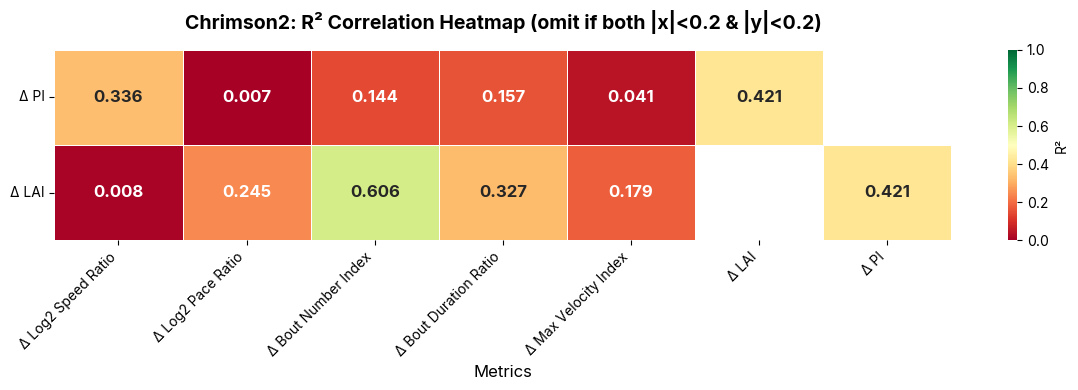


R² values table:
       Δ Log2 Speed Ratio  Δ Log2 Pace Ratio  Δ Bout Number Index  Δ Bout Duration Ratio  Δ Max Velocity Index  Δ LAI   Δ PI
Δ PI                0.336              0.007                0.144                  0.157                 0.041  0.421    NaN
Δ LAI               0.008              0.245                0.606                  0.327                 0.179    NaN  0.421


In [34]:
# Heatmap uses the same per-plot omission logic as scatter plots above
# Threshold for omission - if BOTH x and y values are below this magnitude, omit that MBON
omission_threshold = 0.2

for row_idx, y_var in enumerate(y_vars):
    for col_idx, metric in enumerate(metrics):
        y_col = y_var + suffix if y_var + suffix in df_plot.columns else y_var
        x_col = metric + suffix if metric + suffix in df_plot.columns else metric
        
        if x_col not in df_plot.columns or y_col not in df_plot.columns:
            r2_matrix[row_idx, col_idx] = np.nan
            continue
        
        if y_var in metric:
            r2_matrix[row_idx, col_idx] = np.nan
            continue
        
        df_clean = df_plot[[x_col, y_col]].dropna()
        
        # Per-plot omission: remove rows where BOTH x and y are below threshold magnitude
        df_clean = df_clean[~((df_clean[x_col].abs() < omission_threshold) & (df_clean[y_col].abs() < omission_threshold))]
        
        if len(df_clean) < 3:
            r2_matrix[row_idx, col_idx] = np.nan
            continue
        
        pearson_result = scipy.stats.pearsonr(df_clean[x_col], df_clean[y_col])
        r2_matrix[row_idx, col_idx] = pearson_result[0] ** 2

# Create DataFrame for heatmap
metric_labels = metrics.copy()
y_labels = y_vars.copy()
r2_df = pd.DataFrame(r2_matrix, index=y_labels, columns=metric_labels)

# Create heatmap
fig_heatmap, ax_heatmap = plt.subplots(figsize=(12, 4))

# Plot heatmap with annotations
heatmap = sns.heatmap(r2_df, 
                       annot=True, 
                       fmt='.3f',
                       cmap='RdYlGn',  # Red (low) to Green (high)
                       vmin=0, 
                       vmax=1,
                       linewidths=0.5,
                       linecolor='white',
                       cbar_kws={'label': 'R²'},
                       annot_kws={'fontsize': 12, 'weight': 'bold'},
                       ax=ax_heatmap)

# Style the heatmap
ax_heatmap.set_title(f'{title_prefix}: R² Correlation Heatmap (omit if both |x|<{omission_threshold} & |y|<{omission_threshold})', fontsize=14, weight='bold', pad=15)
ax_heatmap.set_xlabel('Metrics', fontsize=12)
ax_heatmap.set_ylabel('', fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

fig_heatmap.tight_layout()
plt.show()

# Print R² values as a table for reference
print("\nR² values table:")
print(r2_df.round(3).to_string())

## Plotting PI ACR vs PI Chrimson2

In [16]:
OFFSET = 0.0018  
CHAR_WIDTH = 0.06  
CHAR_HEIGHT = 0.08  
LABEL_MARGIN = 0.1

def get_label_bbox(x, y, label_text, ha, va):
    width = len(label_text) * CHAR_WIDTH
    height = CHAR_HEIGHT
    
    # Adjust x based on horizontal alignment
    if ha == 'left':
        x_min, x_max = x, x + width
    elif ha == 'right':
        x_min, x_max = x - width, x
    else:  # center
        x_min, x_max = x - width/2, x + width/2
    
    # Adjust y based on vertical alignment
    if va == 'bottom':
        y_min, y_max = y, y + height
    elif va == 'top':
        y_min, y_max = y - height, y
    else:  # center
        y_min, y_max = y - height/2, y + height/2
    
    return (x_min, y_min, x_max, y_max)

def boxes_overlap(box1, box2):

    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # No overlap if one box is completely to the side or above/below the other
    if x1_max < x2_min or x2_max < x1_min:
        return False
    if y1_max < y2_min or y2_max < y1_min:
        return False
    return True

def get_best_position(x, y, label_text, all_points, placed_labels, xlim, ylim, label_margin):

    label_len = len(label_text)
    
    # Try multiple distance multipliers (1x, 2x, 3x, 4x the base offset)
    for multiplier in [1, 2, 3, 4]:
        offset_x = OFFSET * label_len * multiplier
        offset_y = OFFSET * 3 * multiplier
        
        # Positions: (dx, dy, horizontal_align, vertical_align)
        positions = {
            'right': (offset_x, 0, 'left', 'center'),
            'left': (-offset_x, 0, 'right', 'center'),
            'above': (0, offset_y, 'center', 'bottom'),
            'below': (0, -offset_y, 'center', 'top'),
            'above_right': (offset_x, offset_y, 'left', 'bottom'),
            'below_right': (offset_x, -offset_y, 'left', 'top'),
            'above_left': (-offset_x, offset_y, 'right', 'bottom'),
            'below_left': (-offset_x, -offset_y, 'right', 'top'),
        }
        
        best_pos = None
        best_score = -np.inf
        
        for pos_name, (dx, dy, ha, va) in positions.items():
            label_x, label_y = x + dx, y + dy
            
            # Get bounding box for this potential label position
            new_bbox = get_label_bbox(label_x, label_y, label_text, ha, va)
            
            # Check if label would be outside plot boundaries
            if new_bbox[0] < xlim[0] + label_margin or new_bbox[2] > xlim[1] - label_margin:
                continue
            if new_bbox[1] < ylim[0] + label_margin or new_bbox[3] > ylim[1] - label_margin:
                continue
            
            # Check for overlap with already-placed labels
            has_overlap = False
            for placed_bbox in placed_labels:
                if boxes_overlap(new_bbox, placed_bbox):
                    has_overlap = True
                    break
            
            if has_overlap:
                continue
            
            # Calculate minimum distance to any DATA POINT
            min_dist_points = np.inf
            for px, py in all_points:
                if px == x and py == y:
                    continue
                dist = np.sqrt((label_x - px)**2 + (label_y - py)**2)
                min_dist_points = min(min_dist_points, dist)
            
            score = min_dist_points
            
            if score > best_score:
                best_score = score
                best_pos = pos_name
        
        # If we found a valid position at this multiplier, return it
        if best_pos is not None:
            return positions[best_pos]
    
    # If no valid position found after all multipliers, warn and return default
    print(f"WARNING: Could not find non-overlapping position for '{label_text}'")
    # Return a fallback position (right, with largest offset tried)
    offset_x = OFFSET * label_len * 4
    offset_y = OFFSET * 3 * 4
    return (offset_x, 0, 'left', 'center')

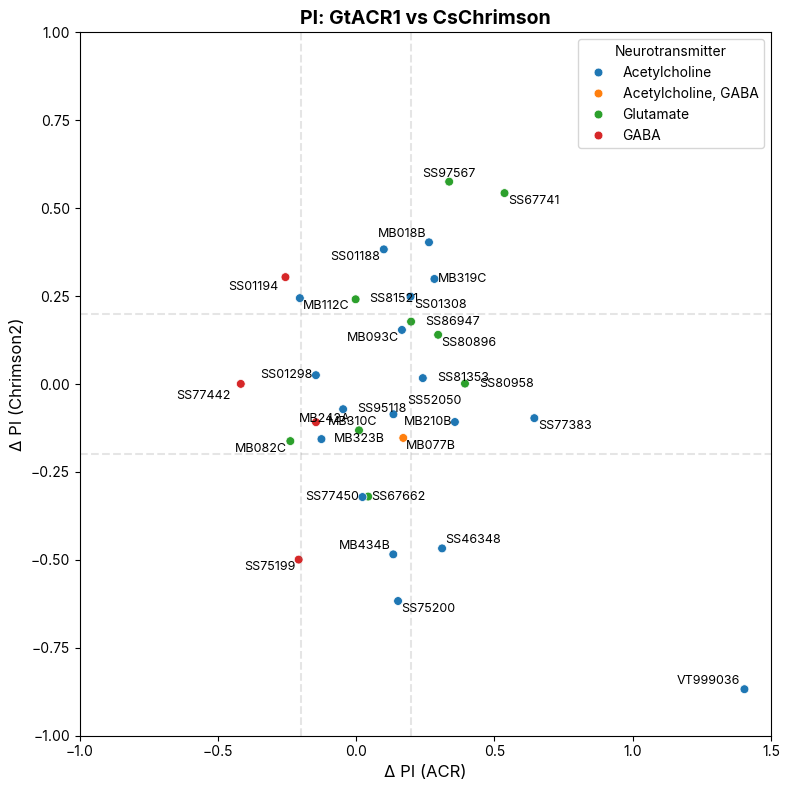

In [ ]:
import scipy.stats
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')

plt.rcParams["font.family"] = "Inter"

mbons_to_omit = ['R76B09'] 

xlim = [-1, 1.5]
ylim = [-1, 1]

mbons_acr = set(dfmultiresponderosar[dfmultiresponderosar['responder'] == 'ACR']['MBON'])
mbons_cr2 = set(dfmultiresponderosar[dfmultiresponderosar['responder'] == 'Chrimson2']['MBON'])
mbons_both = mbons_acr & mbons_cr2  

df_filtered = dfmultiresponderosar[dfmultiresponderosar['MBON'].isin(mbons_both)].copy()
df_filtered = df_filtered[~df_filtered['MBON'].isin(mbons_to_omit)]  # remove specified MBONs

df_pivot = df_filtered.pivot(index='MBON', columns='responder', values='Δ PI').reset_index()



figosarplot, axscatter_o = plt.subplots(figsize=(8, 8))

sns.scatterplot(x="ACR", y="Chrimson2", data=df_pivot, s=40, hue = lobelocation ['Neurotransmitter'], ax=axscatter_o)

axscatter_o.set_xlabel('Δ PI (ACR)', fontsize=12)
axscatter_o.set_ylabel('Δ PI (Chrimson2)', fontsize=12)

axscatter_o.set_xlim(xlim)
axscatter_o.set_ylim(ylim)

axscatter_o.axvline(-.2, c=(.5, .5, .5), ls='--', alpha=0.2)
axscatter_o.axhline(.2, c=(.5, .5, .5), ls='--', alpha=0.2)
axscatter_o.axvline(.2, c=(.5, .5, .5), ls='--', alpha=0.2)
axscatter_o.axhline(-.2, c=(.5, .5, .5), ls='--', alpha=0.2)
    
axscatter_o.set_title("PI: GtACR1 vs CsChrimson", weight="bold", fontsize=14)

all_points = list(zip(df_pivot['ACR'], df_pivot['Chrimson2']))

placed_labels = []

for idx, row in df_pivot.iterrows():
    label_text = row['MBON']
    dx, dy, ha, va = get_best_position(
        row['ACR'], row['Chrimson2'], label_text, all_points, placed_labels, xlim, ylim, LABEL_MARGIN
    )
    label_x = row['ACR'] + dx
    label_y = row['Chrimson2'] + dy
    
    axscatter_o.annotate(label_text, 
                         xy=(row['ACR'], row['Chrimson2']),
                         xytext=(label_x, label_y),
                         fontsize=9, ha=ha, va=va)
    
    bbox = get_label_bbox(label_x, label_y, label_text, ha, va)
    placed_labels.append(bbox)

plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none' 
#plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date+ "_comparison of ACR and Cr2.svg")

## single MBON lin regression (reg by PI)

In [ ]:
import seaborn as sns

#dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full')].copy()
dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full') & (df2['status'] == 'Offspring')].copy()
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)

nama = basegenotype

dfx = pd.DataFrame()

for each in nama:
    dfy = dfi[(dfi['MBON'] == each)]
    dfx = pd.concat([dfx, dfy])
    
osar_data = dfx

c:\Users\user\anaconda3\lib\site-packages\pandas\plotting\_matplotlib\core.py:1114: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


Text(0.5, 0, 'Absolute PI Mean Diff')

<Figure size 2000x2000 with 0 Axes>

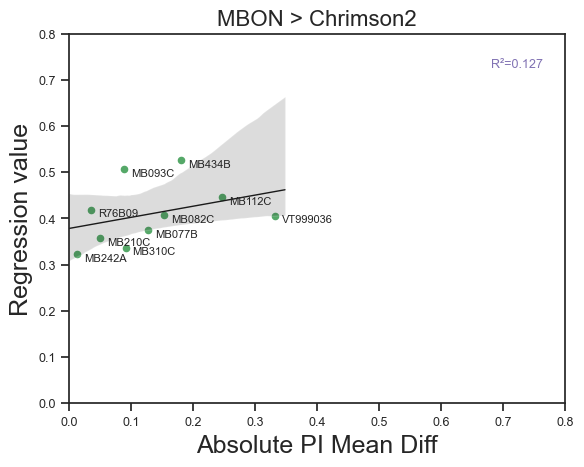

In [ ]:
totalmdtabs = totalmdt.copy().reset_index(drop=False)
totalmdtabs['PI MeanDiff'] = abs(totalmdtabs['PI MeanDiff'])

plt_1 = plt.figure(figsize=(20, 20), dpi = 100)

plt_1= totalmdtabs.plot(kind = 'scatter', x= 'PI MeanDiff', y = 'Regression value', color = "g");

sns.regplot(x = totalmdtabs['PI MeanDiff'],
                y = totalmdtabs['Regression value'],
                scatter=False,
                line_kws={'lw':1}, 
                color="k",
                truncate=False)

x = totalmdtabs['PI MeanDiff'].to_numpy()
y = totalmdtabs['Regression value'].to_numpy()

finiteMask = np.isfinite([x, y]).all(axis=0)

corr = sp.stats.linregress(x[finiteMask], y[finiteMask])
lowers, uppers = skb.ci((x[finiteMask], y[finiteMask]), 
                        statfunction=r2_and_slope, 
                        n_samples=3000)

r2 = np.round(corr.rvalue**2, 3)
r2_lower = np.round(lowers[0], 3)
r2_upper = np.round(uppers[0], 3)

plt_1.annotate('R\u00b2='+str("{:.3f}".format(r2)), 
                        xy=(0.85, 0.90),  # xy coords
                        xycoords='axes fraction',
                        ha='left', va='bottom', color = "m",
                        fontsize=9)


for idx, row in totalmdtabs.iterrows():
    plt_1.annotate(row['MBON' ], (row['PI MeanDiff'], row['Regression value']), xytext=(5,-5),
                textcoords='offset points', family='sans-serif', fontsize=8)
plt_1.set_xlim(0, 0.8)
plt_1.set_ylim(0, 0.8)
plt_1.tick_params(axis='x', labelsize=9)
plt_1.tick_params(axis='y', labelsize=9)
plt_1.set_title("MBON > " + respondertype, fontsize = 16)
plt_1.set_xlabel('Absolute PI Mean Diff')

## Regression by genotypes (PI vs SR)

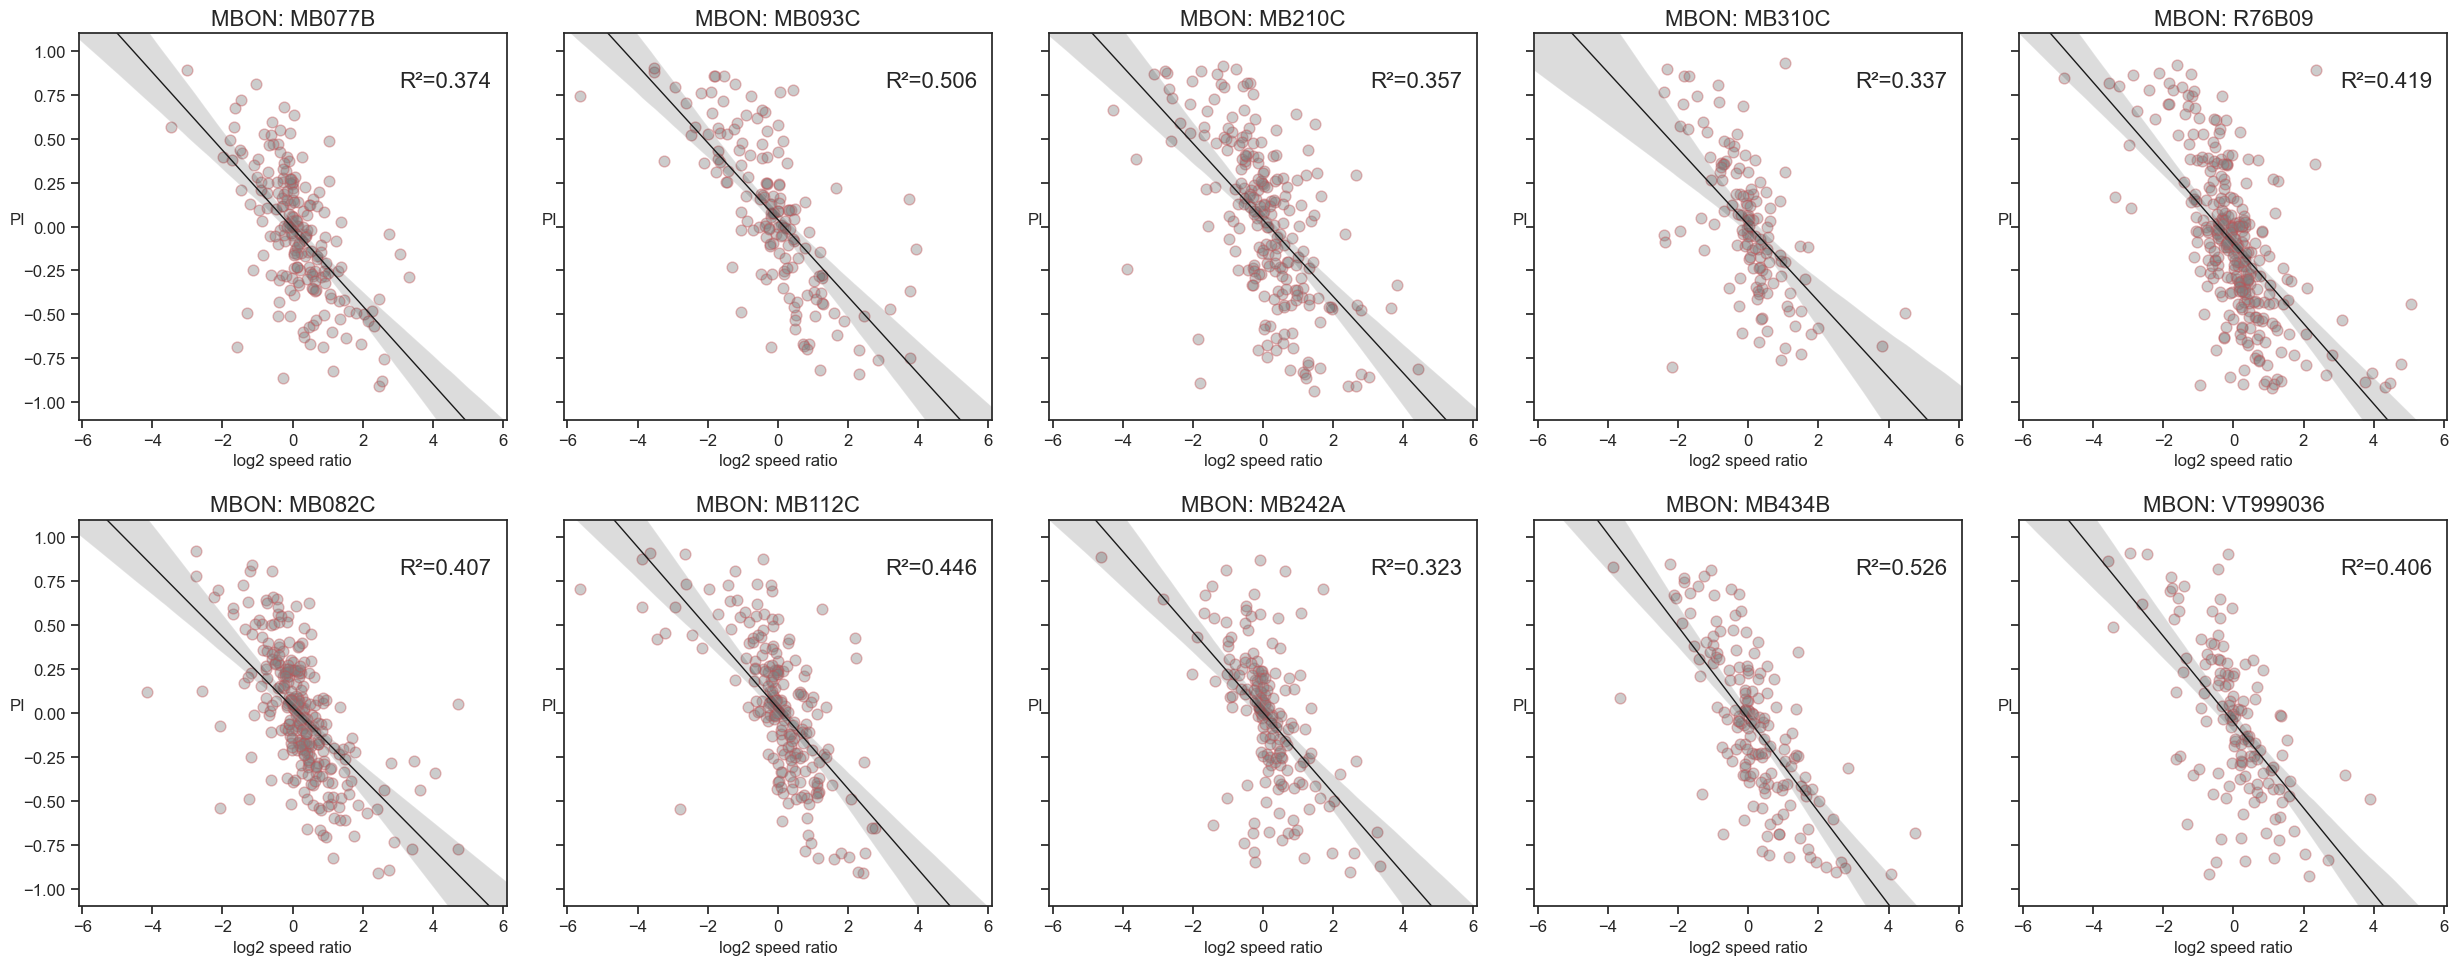

In [ ]:
f, ax = plt.subplots(nrows=2, ncols=5,figsize=(25,10), sharey = True)  #ACR

for name, row, col in zip(basegenotype, 5*[0,1], 2*[0]+2*[1]+2*[2]+2*[3]+2*[4]+2*[5]): #ACR

    df=osar_data[osar_data['MBON']==name]

    ax[row][col].set_ylim(-1.1,1.1)  
    ax[row][col].set_xlim(-6.1,6.1) 
    ax[row][col].tick_params(axis='x', labelsize= 12)
    ax[row][col].tick_params(axis='y', labelsize= 12)

    ax[row][col].scatter(df['log2_speed_ratio_Pattern 01'], 
            df['pi_smoothed_Pattern 01'],
            color='grey',
            edgecolors="r",
            alpha=0.4, 
            s=60)

                    
    sns.regplot(x = df['log2_speed_ratio_Pattern 01'],
                    y = df['pi_smoothed_Pattern 01'],
                    scatter=False,
                    line_kws={'lw':1}, 
                    color="k",
                    ax=ax[row][col],
                    truncate=False)

    x = df['log2_speed_ratio_Pattern 01'].to_numpy()
    y = df['pi_smoothed_Pattern 01'].to_numpy()

    finiteMask = np.isfinite([x, y]).all(axis=0)

    corr = sp.stats.linregress(x[finiteMask], y[finiteMask])
    lowers, uppers = skb.ci((x[finiteMask], y[finiteMask]), 
                            statfunction=r2_and_slope, 
                            n_samples=3000)

    r2 = np.round(corr.rvalue**2, 3)
    r2_lower = np.round(lowers[0], 3)
    r2_upper = np.round(uppers[0], 3)

    ax[row][col].annotate('R\u00b2='+str("{:.3f}".format(r2)), 
                            xy=(0.75, 0.85),  # xy coords
                            xycoords='axes fraction',
                            ha='left', va='bottom',
                            fontsize=16)


    ax[row][col].set_ylabel('PI', rotation = 0, fontsize=12)
    ax[row][col].set_xlabel('log2 speed ratio', fontsize=12)
    ax[row][col].set_title("MBON: "+ name, fontsize = 16)


f.tight_layout()

#f.savefig("D:\\Nicole Lee - HDD\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\osar_compiled\\Figure\\regressionhalffull" + date + ".png")